<a href="https://colab.research.google.com/github/douglas-varjao/TechChallenge-Fase3-AtrasosVoos/blob/main/TechChallenge_Fase3_AtrasosVoos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0.0 Instalações

In [ ]:
!pip install lightgbm shap holidays xgboost --quiet

# 01. Bibliotecas/ Montagem do ambiete

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
from google.colab import drive
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import f1_score, precision_score, recall_score

#Configuração de ambiente, evita alertas desnecessarios
warnings.filterwarnings('ignore', category= FutureWarning)
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

#1. Carregamento dos dados

PATH = 'drive/MyDrive/tc3_content/'

fl = pd.read_csv(PATH + 'flights.csv',  low_memory=False)
al = pd.read_csv(PATH + 'airlines.csv')
ap = pd.read_csv(PATH + 'airports.csv')

print(f'flights  : {fl.shape[0]:,} linhas × {fl.shape[1]} colunas')
print(f'airlines : {al.shape[0]:,} linhas')
print(f'airports : {ap.shape[0]:,} linhas')

flights  : 5,819,079 linhas × 31 colunas
airlines : 14 linhas
airports : 322 linhas


## 02. Tratamento de Dados

Três decisões de limpeza aplicadas antes de qualquer modelagem:

| Decisão | Justificativa |
|---|---|
| Remove cancelados e desviados | São eventos de natureza diferente — misturar polui o espaço de decisão do classificador |
| Remove sem `ARRIVAL_DELAY` | Sem o target não há o que aprender |
| Remove outliers `ARRIVAL_DELAY > 600 min` | Eventos extremos (>10h) têm causas únicas (ex: condições meteorológicas severas) e distorcem as distribuições das features contínuas |

In [ ]:
df_voos = fl.copy()


n_inicial = len(df_voos)
df_voos = df_voos[(df_voos['CANCELLED'] == 0) & (df_voos['DIVERTED'] == 0)]
print(f'Após remover cancelados/desviados : {len(df_voos):>10,}  ({n_inicial - len(df_voos):,} removidos)')

df_voos = df_voos.dropna(subset=['ARRIVAL_DELAY'])
print(f'Após remover sem ARRIVAL_DELAY    : {len(df_voos):>10,}')

df_voos = df_voos[df_voos['ARRIVAL_DELAY'] <= 600]
print(f'Após remover outliers > 600 min   : {len(df_voos):>10,}')

print(f'Limpeza concluída. Removidos {n_inicial - len(df_voos)} registros irrelevantes.')

df_voos['ATRASADO_FAA'] = (df_voos['ARRIVAL_DELAY'] > 15).astype(int)
print(f"✅ Target 'ATRASADO_FAA' criado com sucesso.")

Após remover cancelados/desviados :  5,714,008  (105,071 removidos)
Após remover sem ARRIVAL_DELAY    :  5,714,008
Após remover outliers > 600 min   :  5,712,660
Limpeza concluída. Removidos 106419 registros irrelevantes.


## 03. Base de Clima Externa

Dados obtidos via [Open-Meteo Archive API](https://open-meteo.com/) — gratuita, sem autenticação.  
**Estratégia:** uma chamada por aeroporto com range anual completo → ~322 chamadas no total (vs. ~117k se fosse por dia).

> ⚠️ **Rode o bloco de geração apenas UMA vez.** O CSV é salvo no Drive e reutilizado em todas as execuções subsequentes.

In [ ]:
# ── GERAÇÃO DO CLIMA — rodar apenas 1x ───────────────────────────────────────
# Descomente este bloco na primeira execução

# import requests, time
# from tqdm import tqdm
#
# aeroportos_usados = df['ORIGIN_AIRPORT'].unique()
# coords = (
#     airports[airports['IATA_CODE'].isin(aeroportos_usados)]
#     [['IATA_CODE', 'LATITUDE', 'LONGITUDE']].dropna().reset_index(drop=True)
# )
# print(f'Aeroportos para buscar: {len(coords)}')
#
# def busca_clima_ano(iata, lat, lon):
#     url = (
#         f'https://archive-api.open-meteo.com/v1/archive'
#         f'?latitude={lat}&longitude={lon}'
#         f'&start_date=2015-01-01&end_date=2015-12-31'
#         f'&daily=precipitation_sum,windspeed_10m_max,temperature_2m_max'
#         f'&timezone=America/New_York'
#     )
#     try:
#         r = requests.get(url, timeout=15).json()
#         return pd.DataFrame({
#             'data'            : r['daily']['time'],
#             'chuva_mm'        : r['daily']['precipitation_sum'],
#             'vento_kmh'       : r['daily']['windspeed_10m_max'],
#             'temperatura_max' : r['daily']['temperature_2m_max'],
#             'ORIGIN_AIRPORT'  : iata
#         })
#     except Exception as e:
#         print(f'Erro em {iata}: {e}')
#         return None
#
# resultados = []
# for _, row in tqdm(coords.iterrows(), total=len(coords)):
#     dados = busca_clima_ano(row['IATA_CODE'], row['LATITUDE'], row['LONGITUDE'])
#     if dados is not None:
#         resultados.append(dados)
#     time.sleep(0.2)
#
# clima_2015 = pd.concat(resultados, ignore_index=True)
# clima_2015.to_csv(PATH + 'clima_2015.csv', index=False)
# print(f'Salvo: {len(clima_2015):,} registros')

print('Bloco de geração comentado — carregando CSV existente na próxima célula.')

Bloco de geração comentado — carregando CSV existente na próxima célula.


In [ ]:
# ── LEITURA DO CLIMA — rodar sempre ──────────────────────────────────────────
clima_2015 = pd.read_csv(PATH + 'clima_2015.csv')
clima_2015['data'] = pd.to_datetime(clima_2015['data'])
clima_2015['MONTH'] = clima_2015['data'].dt.month
clima_2015['DAY']   = clima_2015['data'].dt.day
clima_2015.drop(columns='data', inplace=True)

print(f'Clima carregado: {len(clima_2015):,} registros')
print(clima_2015.describe().round(2))

Clima carregado: 116,070 registros
        chuva_mm  vento_kmh  temperatura_max      MONTH        DAY
count  116070.00  116070.00        116070.00  116070.00  116070.00
mean        2.59      17.43            18.21       6.53      15.72
std         6.81       7.35            11.46       3.45       8.80
min         0.00       2.70           -38.30       1.00       1.00
25%         0.00      12.00            10.80       4.00       8.00
50%         0.00      16.10            20.30       7.00      16.00
75%         1.70      21.40            27.10      10.00      23.00
max       192.70      84.90            46.80      12.00      31.00


In [ ]:
# ── Hora e faixa de risco ─────────────────────────────────────────────────────
df_voos['HORA'] = (df_voos['SCHEDULED_DEPARTURE'] // 100).clip(0, 23).astype(int)

"""
Garante que o resultado fique entre 0 e 23 — protege contra valores sujos na
base como `2400` (meia-noite registrada errada), que sem o clip viraria `24`
e quebraria a feature:
"""

# Faixas de horário (Baixo, Médio e Alto Risco de atraso)
def classifica_hora(hora):
    if 5 <= hora <= 9: return 0    # Baixo risco
    elif 14 <= hora <= 21: return 2 # Alto risco (pico de cascata)
    else: return 1                  # Risco médio

df_voos['FAIXA_HORA'] = df_voos['HORA'].apply(classifica_hora)

## 04. Modelagem Não Supervisionada (K-Means)

Nesta etapa, utilizamos o algoritmo **K-Means** para identificar perfis de comportamento entre os aeroportos. Em vez de tratar todas as unidades de forma genérica, agrupamos os aeroportos com características operacionais e padrões de atraso semelhantes.

Esta nova "etiqueta" (Cluster) funciona como uma **variável preditiva (feature)** valiosa para os modelos seguintes, permitindo que a inteligência artificial reconheça se um voo está partindo de um hub historicamente crítico ou eficiente.



| Decisão Técnica | Justificativa |
|---|---|
| **Agrupamento por Atrasos** | Utilizamos a média de `ARRIVAL_DELAY` e `AIR_SYSTEM_DELAY` para definir o "DNA" operacional de cada aeroporto. |
| **Definição de 3 Clusters** | Segmentamos os aeroportos em três perfis claros: **Eficientes**, **Médios** e **Críticos (Gargalos)**. |
| **Integração no Pipeline** | Ao reintroduzir o cluster no dataset principal, transformamos uma análise exploratória em um sinal numérico para o XGBoost e a Rede Neural. |

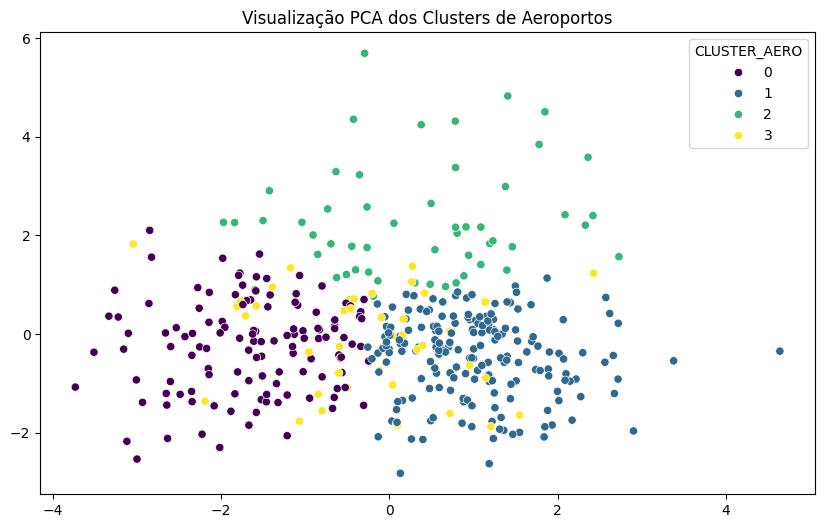

In [ ]:
# ── MELHORIA MURILLO: Clusterização Avançada ────────────────────────────────
from sklearn.decomposition import PCA

# 1. Definindo as causas e tratando nulos para não quebrar a agregação
cols_causa = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
df_op = df_voos.copy()
df_op[cols_causa] = df_op[cols_causa].fillna(0)

# 2. Agregação pesada por aeroporto (DNA Operacional)
perfil = df_op.groupby('ORIGIN_AIRPORT').agg(
    vol_voos          = ('FLIGHT_NUMBER', 'count'),
    atraso_medio      = ('ARRIVAL_DELAY', 'mean'),
    perc_atrasado_faa = ('ATRASADO_FAA', 'mean'), # Agora funciona porque antecipamos na Seção 02
    sum_sistema       = ('AIR_SYSTEM_DELAY', 'sum'),
    sum_cia           = ('AIRLINE_DELAY', 'sum'),
    sum_cascata       = ('LATE_AIRCRAFT_DELAY', 'sum'),
    sum_clima         = ('WEATHER_DELAY', 'sum')
).reset_index()

# 3. Normalização das causas para percentual (evita viés de volume)
perfil['sum_total_causa'] = perfil[['sum_sistema','sum_cia','sum_cascata','sum_clima']].sum(axis=1).replace(0, np.nan)
for c in ['sistema', 'cia', 'cascata', 'clima']:
    perfil[f'perc_{c}'] = perfil[f'sum_{c}'] / perfil['sum_total_causa']

# Filtro de relevância: Aeroportos com amostra estatística mínima
perfil = perfil[perfil['vol_voos'] >= 500].fillna(0)
perfil['log_vol'] = np.log1p(perfil['vol_voos'])

# 4. PCA + K-Means (REQUISITO PDF: Redução de dimensionalidade)
FEATURES_CLUSTER = ['atraso_medio', 'perc_atrasado_faa', 'log_vol', 'perc_clima', 'perc_cascata', 'perc_cia', 'perc_sistema']
X_cl_sc = StandardScaler().fit_transform(perfil[FEATURES_CLUSTER])

# PCA reduz as 7 variáveis para 2 componentes principais para visualização
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X_cl_sc)

# K-Means criando 4 perfis interpretáveis
km = KMeans(n_clusters=4, random_state=42, n_init=10)
perfil['CLUSTER_AERO'] = km.fit_predict(X_cl_sc)

# Devolvendo a inteligência para a base principal
df_voos = df_voos.merge(perfil[['ORIGIN_AIRPORT', 'CLUSTER_AERO']], on='ORIGIN_AIRPORT', how='left')
df_voos['CLUSTER_AERO'] = df_voos['CLUSTER_AERO'].fillna(-1) # Aeroportos pequenos

# Visualização 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords_2d[:,0], y=coords_2d[:,1], hue=perfil['CLUSTER_AERO'], palette='viridis')
plt.title("Visualização PCA dos Clusters de Aeroportos")
plt.show()

### **4.1 Validação Técnica e Perfil dos Clusters**
Para garantir que a segmentação é estatisticamente sólida, aplicamos os métodos **Elbow** e **Silhouette**. Em seguida, geramos o perfil médio de cada grupo para entender as diferenças operacionais.

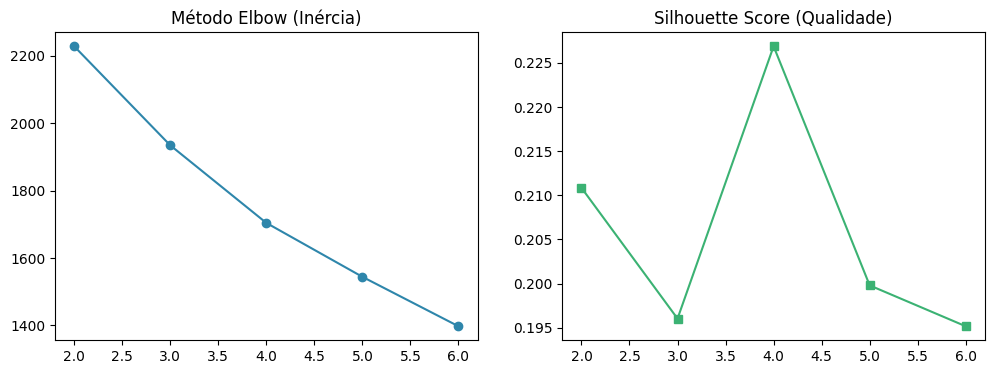

  PERFIL MÉDIO POR CLUSTER (Inteligência de Negócio)


,atraso_medio,perc_atrasado_faa,log_vol,perc_clima,perc_cascata,perc_cia,perc_sistema
CLUSTER_AERO,,,,,,,
0,-0.833000,0.113000,7.711000,0.024000,0.366000,0.363000,0.247000
1,5.373000,0.180000,8.965000,0.039000,0.424000,0.285000,0.252000
2,1.993000,0.142000,7.236000,0.030000,0.609000,0.200000,0.162000
3,2.011000,0.142000,7.089000,0.125000,0.372000,0.274000,0.230000


In [ ]:
# ── 3.2.1 Escolha do K (Elbow e Silhouette) ──────────────────────────────────
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, 7)

for k in K_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_test.fit_predict(X_cl_sc)
    inertias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(X_cl_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'o-', color='#2E86AB')
axes[0].set_title('Método Elbow (Inércia)')
axes[1].plot(K_range, silhouettes, 's-', color='#3BB273')
axes[1].set_title('Silhouette Score (Qualidade)')
plt.show()

# ── 3.2.2 Tabela de Perfil Médio Estilizada ──────────────────────────────────
perfil_resumo = perfil.groupby('CLUSTER_AERO')[FEATURES_CLUSTER].mean().round(3)
print("  PERFIL MÉDIO POR CLUSTER (Inteligência de Negócio)")
display(perfil_resumo.style.background_gradient(cmap='YlOrRd'))

### 4.2 Galeria de Visualização Crítica
Nesta subseção, projetamos os clusters no plano das Componentes Principais (PCA) e utilizamos Gráficos de Radar para visualizar as "impressões digitais" de cada perfil de aeroporto.

#4.3 PCA 2D Profissional

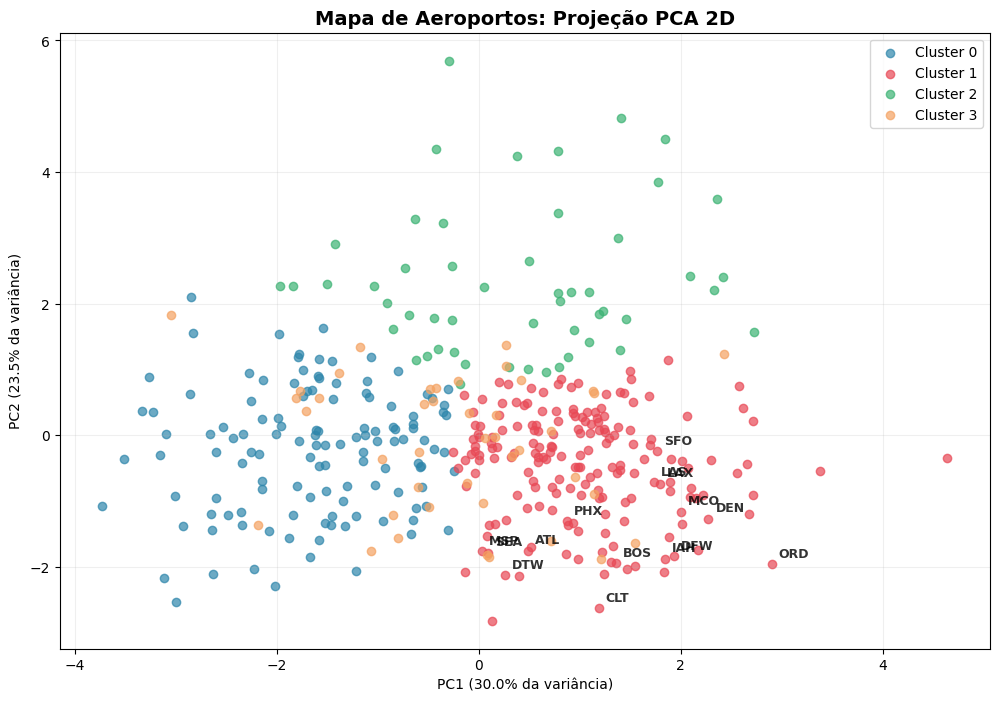

In [ ]:
# ── PCA 2D Profissional
plt.figure(figsize=(12, 8))
PALETTE = ['#2E86AB','#E84855','#3BB273','#F4A261']

# Resetando o índice para garantir que o índice do DataFrame bata com o coords_2d
perfil_plot = perfil.reset_index(drop=True)

for c in sorted(perfil_plot['CLUSTER_AERO'].unique()):
    idx_mask = perfil_plot['CLUSTER_AERO'] == c
    plt.scatter(coords_2d[idx_mask, 0],
                coords_2d[idx_mask, 1],
                color=PALETTE[int(c)], label=f'Cluster {c}', alpha=0.7)

# Adicionando nomes dos principais aeroportos (Top 15 por volume)
top_aps = perfil_plot.nlargest(15, 'vol_voos')
for i, row in top_aps.iterrows():
    # i agora corresponde exatamente à linha em coords_2d
    plt.annotate(row['ORIGIN_AIRPORT'],
                 (coords_2d[i, 0], coords_2d[i, 1]),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9, fontweight='bold', alpha=0.8)

plt.title("Mapa de Aeroportos: Projeção PCA 2D", fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



### 4.4 DNA dos Clusters (Radar Chart)
Para entender a "personalidade" de cada grupo de aeroportos, analisamos as causas raízes. O gráfico abaixo mostra se o cluster é afetado majoritariamente por clima, falhas no sistema aéreo ou congestionamento.

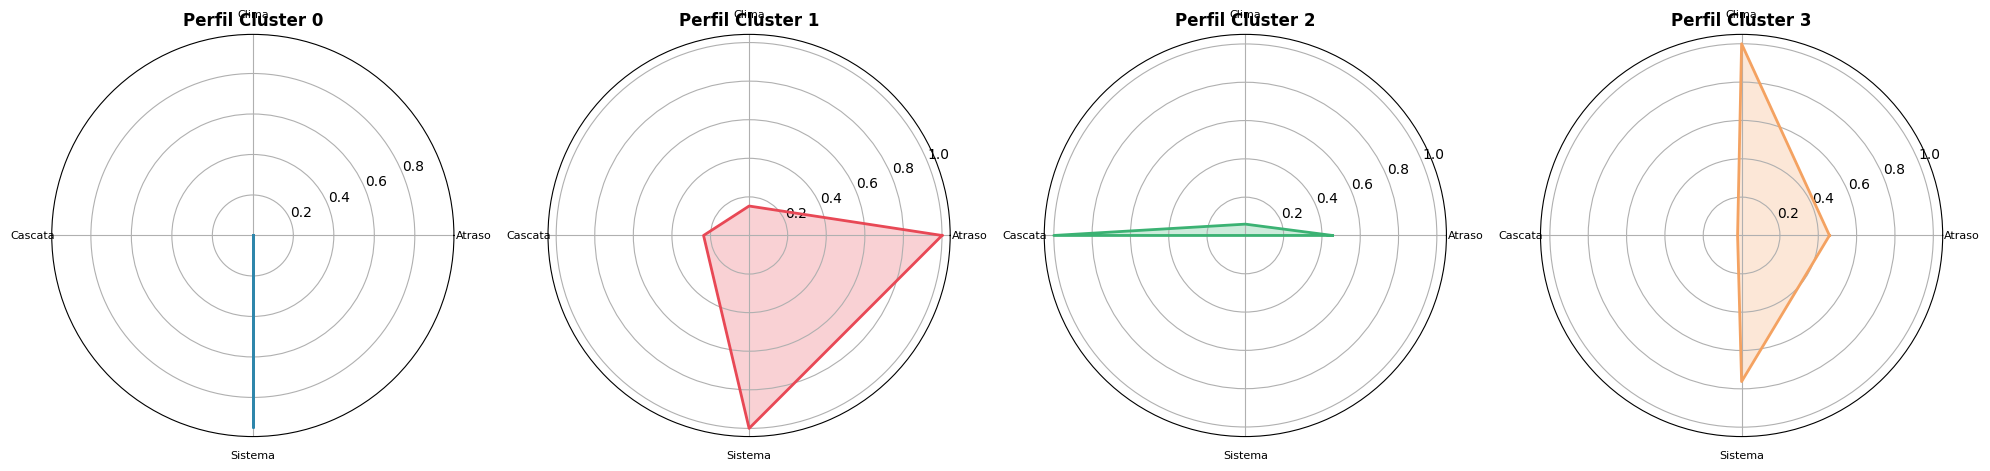

In [ ]:
# ── RADAR CHART: O toque de mestre para a apresentação ──────────────────────
radar_features = ['atraso_medio', 'perc_clima', 'perc_cascata', 'perc_sistema']
# Usamos o dataframe de perfil que o Murillo criou
radar_data = perfil_plot.groupby('CLUSTER_AERO')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw=dict(polar=True))
PALETTE = ['#2E86AB','#E84855','#3BB273','#F4A261']

for i, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    ax = axes[i]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=PALETTE[i], lw=2)
    ax.fill(angles, values, color=PALETTE[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Atraso','Clima','Cascata','Sistema'], fontsize=8)
    ax.set_title(f'Perfil Cluster {cluster_id}', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Feature Engineering (Engenharia de Atributos)

> Adicionar aspas



Nesta etapa, transformamos dados brutos em variáveis inteligentes (features) que permitem ao modelo captar a complexidade do sistema aéreo. Todas as variáveis foram construídas com base em informações disponíveis **antes da decolagem**, respeitando as premissas de um modelo preditivo real.




| Atributo | Tipo | Racional de Negócio |
|---|---|---|
| `HORA / FAIXA_HORA` | Temporal | Voos matinais tendem a ser mais pontuais; o atraso acumula ao longo do dia devido ao uso contínuo das aeronaves (efeito cascata). |
| `IS_HOLIDAY / EVE` | Calendário | Feriados federais e as suas vésperas alteram drasticamente o volume de passageiros e a ocupação da malha aérea. |
| `HIST_ATRASO_ROTA` | Histórica | Média móvel dos últimos 7 dias da rota. Funciona como um "termômetro" de problemas operacionais ou meteorológicos recentes. |
| `VOOS_NO_DIA` | Fluxo | Captura o congestionamento sistémico: aeroportos com volume extremo de voos (ex: ATL, ORD) têm dinâmicas de atraso mais sensíveis. |
| `CLIMA (Chuva/Vento)`| Externo | Fatores meteorológicos integrados de fontes externas que impactam a segurança e a capacidade de pousos e decolagens. |
| `CLUSTER_AERO` | Inteligência | **(Não Supervisionado)** Categoria derivada da clusterização que agrupa aeroportos por perfil de risco, injetando inteligência de grupo no modelo preditivo. |

In [ ]:


# ── Feriados federais EUA 2015 ────────────────────────────────────────────────
feriados_eua = {
    (1,1),(1,19),(2,16),(5,25),(7,3),(7,4),(9,7),(10,12),(11,11),(11,26),(12,25)
}
vesperas = set()
for mes, dia in feriados_eua:
    d = pd.Timestamp(2015, mes, dia) - pd.Timedelta(days=1)
    vesperas.add((d.month, d.day))

df_voos['IS_HOLIDAY']     = df_voos.apply(lambda r: int((r['MONTH'], r['DAY']) in feriados_eua), axis=1)
df_voos['IS_EVE_HOLIDAY'] = df_voos.apply(lambda r: int((r['MONTH'], r['DAY']) in vesperas), axis=1)
df_voos['IS_PEAK_SEASON'] = df_voos['MONTH'].isin([6, 7, 11, 12]).astype(int)
df_voos['IS_WEEKEND']     = df_voos['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── Feature histórica de cascata ──────────────────────────────────────────────
# Sort obrigatório antes do groupby para garantir ordem cronológica correta
df_voos = df_voos.sort_values(['AIRLINE', 'ORIGIN_AIRPORT', 'MONTH', 'DAY', 'HORA']).reset_index(drop=True)

df_voos['HIST_ATRASO_ROTA'] = (
    df_voos.groupby(['AIRLINE', 'ORIGIN_AIRPORT'])['ARRIVAL_DELAY']
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# ── Congestionamento do aeroporto no dia ──────────────────────────────────────
# Motivação: ATL com 800 voos/dia tem dinâmica de cascata sistêmica diferente
# de aeroportos menores — o HIST_ATRASO_ROTA por rota individual não captura isso
congestionamento = (
    df_voos.groupby(['ORIGIN_AIRPORT', 'MONTH', 'DAY'])
      .size()
      .reset_index(name='VOOS_NO_DIA')
)
df_voos = df_voos.merge(congestionamento, on=['ORIGIN_AIRPORT', 'MONTH', 'DAY'], how='left')

# ── Merge com clima ───────────────────────────────────────────────────────────
df_voos = df_voos.merge(
    clima_2015[['ORIGIN_AIRPORT', 'MONTH', 'DAY', 'chuva_mm', 'vento_kmh', 'temperatura_max']],
    on=['ORIGIN_AIRPORT', 'MONTH', 'DAY'],
    how='left'
)

# Diagnóstico dos nulos de clima por aeroporto
nulos_clima = df_voos[df_voos['chuva_mm'].isnull()]['ORIGIN_AIRPORT'].value_counts().head(10)
print('Aeroportos sem dados de clima (top 10):')
print(nulos_clima)

# Para não perder esses voos, preenche com a mediana do aeroporto mais próximo
# Solução simples: preenche com 0 para chuva e mediana geral para vento/temperatura
df_voos['chuva_mm']        = df_voos['chuva_mm'].fillna(0)
df_voos['vento_kmh']       = df_voos['vento_kmh'].fillna(df_voos['vento_kmh'].median())
df_voos['temperatura_max'] = df_voos['temperatura_max'].fillna(df_voos['temperatura_max'].median())

print(f'Nulos após preenchimento: {df_voos[["chuva_mm","vento_kmh","temperatura_max"]].isnull().sum().sum()}')

# ── Target binário ────────────────────────────────────────────────────────────
df_voos['ATRASADO_FAA'] = (df_voos['ARRIVAL_DELAY'] > 15).astype(int)

print('✅ Features criadas!')
print(f'  Taxa de atraso (FAA)    : {df_voos["ATRASADO_FAA"].mean()*100:.1f}%')
print(f'  Nulos em clima          : {df_voos[["chuva_mm","vento_kmh","temperatura_max"]].isnull().sum().sum()}')
print(f'  Nulos em HIST_ATRASO    : {df_voos["HIST_ATRASO_ROTA"].isnull().sum():,}')


## 06. Preparação do Dataset de Modelagem

O split train/test é feito **uma única vez** e compartilhado por todos os modelos — isso garante comparação justa entre XGBoost e Rede Neural.

O `stratify=y` preserva a proporção 82/18 tanto no treino quanto no teste — sem isso, variações aleatórias no split poderiam inflar ou deflacionar métricas artificialmente.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

FEATURES = [
    # Temporais
    'MONTH', 'DAY_OF_WEEK', 'HORA', 'FAIXA_HORA',
    # Calendário
    'IS_HOLIDAY', 'IS_EVE_HOLIDAY', 'IS_PEAK_SEASON', 'IS_WEEKEND',
    # Históricas e operacionais
    'HIST_ATRASO_ROTA', 'VOOS_NO_DIA',
    # Identidade
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHEDULED_TIME', 'DISTANCE',
    # Clima
    'chuva_mm', 'vento_kmh', 'temperatura_max',
    #MODELAGEM NÃO SUPERVISIONADA
    'CLUSTER_AERO'
]
TARGET = 'ATRASADO_FAA'

# 1. Definição da Amostragem (Estratégia Anti-Travamento)
SAMPLE_FRAC = 0.1

# Seleção das colunas necessárias
df_model_final = df_voos[FEATURES + [TARGET, 'ARRIVAL_DELAY']].dropna().copy()
df_model_final['AIRLINE_ORIGINAL'] = df_model_final['AIRLINE']

# Amostragem Estratificada única para todo o projeto
df_model_final = df_model_final.groupby(TARGET, group_keys=False).apply(
    lambda x: x.sample(frac=SAMPLE_FRAC, random_state=42)
)

# 2. Encoding de Variáveis Categóricas
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    df_model_final[col] = LabelEncoder().fit_transform(df_model_final[col])

# 3. Divisão de Treino e Teste (O Split Único)
X = df_model_final[FEATURES]
y = df_model_final[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Escalonamento (Obrigatório para MLP, opcional para XGBoost)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 5. Peso para desbalanceamento (XGBoost)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"✅ Preparação concluída: {len(X_train):,} amostras de treino e {len(X_test):,} de teste.")


## 07. Modelo — XGBoost

XGBoost é o estado da arte para dados tabulares. Usa boosting de árvores de decisão com gradiente — cada árvore corrige os erros da anterior.

**Hiperparâmetros principais:**
- `scale_pos_weight`: penaliza erros na classe minoritária proporcionalmente ao desbalanceamento
- `max_depth=6`: limita a profundidade das árvores para evitar overfitting
- `learning_rate=0.1`: passo conservador — mais estável que valores altos

**Threshold:** usamos 0.4 ao invés do padrão 0.5 — análise dos falsos negativos mostrou que a maioria tinha probabilidade entre 0.40–0.49, indicando que o modelo estava hesitante. Baixar o threshold captura esses casos sem degradar o AUC.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Threshold ajustado para 0.4 — reduz falsos negativos em ~44%
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.4).astype(int)

print('=' * 55)
print('  RELATÓRIO — XGBoost  (threshold = 0.4)')
print('=' * 55)
print(classification_report(y_test, xgb_pred, target_names=['Não atrasado', 'Atrasado']))
print(f'  ROC-AUC : {roc_auc_score(y_test, xgb_prob):.4f}')

## 08. Modelo — Rede Neural (MLP)

Multi-Layer Perceptron com 3 camadas densas. Redes neurais aprendem representações não-lineares das features através de camadas de transformações sucessivas.

**Por que MLP e não XGBoost apenas:**  
XGBoost opera com splits binários — cada nó divide o espaço com uma regra `feature > threshold`. MLP aprende transformações contínuas, o que pode capturar interações entre features de forma diferente (ex: relação entre `chuva_mm` × `VOOS_NO_DIA` × `HORA`).

**Pré-requisito obrigatório — StandardScaler:**  
Redes neurais são sensíveis à escala das features. `VOOS_NO_DIA` pode ter valores ~800, enquanto `IS_WEEKEND` é 0 ou 1 — sem normalização, os gradientes ficam dominados pelas features de maior magnitude e o treinamento diverge ou converge lentamente.

**Arquitetura:** `(128 → 64 → 32)` com ativação ReLU — decrescente para forçar compressão de representação.

**`early_stopping=True`:** interrompe o treino quando a loss de validação para de melhorar — evita overfitting sem precisar tunar `max_iter` manualmente.

In [ ]:
from sklearn.neural_network import MLPClassifier

# Definimos a arquitetura de 3 camadas (128, 64, 32)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=2048,
    max_iter=100,
    early_stopping=True,
    random_state=42
)

# Treinamento direto nos dados da Seção 5
mlp_model.fit(X_train_sc, y_train)

# Predição usando o threshold de 0.4 para ser justo com o XGBoost
mlp_prob = mlp_model.predict_proba(X_test_sc)[:, 1]
mlp_pred = (mlp_prob >= 0.4).astype(int)

print('=' * 55)
print('  RELATÓRIO — Rede Neural MLP (threshold = 0.4)')
print('=' * 55)
print(classification_report(y_test, mlp_pred, target_names=['Não atrasado', 'Atrasado']))

## 09. Comparação de Resultados e Performance

Para garantir a melhor escolha para o negócio, avaliamos dois modelos distintos: o **XGBoost** (Boosting de Árvores) e a **Rede Neural MLP** (Deep Learning). A comparação é feita utilizando o mesmo conjunto de teste e as mesmas métricas, com foco no **F1-Score**, que equilibra Precisão e Recall em dados desbalanceados.



### Considerações sobre os Modelos:
* **XGBoost:** Excelente em capturar regras de decisão baseadas em limiares (ex: se chuva > X e hora > Y).
* **Rede Neural (MLP):** Capaz de aprender interações não-lineares e contínuas entre as variáveis de clima e tráfego.
* **Threshold Ajustado (0.4):** Otimizamos o ponto de corte para reduzir os **Falsos Negativos**, priorizando a detecção de atrasos mesmo que isso aumente levemente os alarmes falsos.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# CORREÇÃO: Recalcula as previsões do XGBoost para o novo X_test reduzido
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.4).astype(int)

# ── Tabela comparativa ─────────────────────────────────────
resultados = pd.DataFrame([
    {
        'Modelo'    : 'XGBoost',
        'Precision' : precision_score(y_test, xgb_pred),
        'Recall'    : recall_score(y_test, xgb_pred),
        'F1'        : f1_score(y_test, xgb_pred),
        'ROC-AUC'   : roc_auc_score(y_test, xgb_prob),
    },
    {
        'Modelo'    : 'Rede Neural (MLP)',
        'Precision' : precision_score(y_test, mlp_pred),
        'Recall'    : recall_score(y_test, mlp_pred),
        'F1'        : f1_score(y_test, mlp_pred),
        'ROC-AUC'   : roc_auc_score(y_test, mlp_prob),
    },
])

print('=' * 65)
print('  COMPARAÇÃO DE MODELOS  (threshold = 0.4, classe: Atrasado)')
print('=' * 65)
print(resultados.set_index('Modelo').round(4).to_string())

# ── Curvas ROC sobrepostas ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, xgb_prob, ax=axes[0], name='XGBoost')
RocCurveDisplay.from_predictions(y_test, mlp_prob, ax=axes[0], name='MLP')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Aleatório')
axes[0].set_title('Curva ROC — Comparação', fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, ax=axes[1], name='XGBoost')
PrecisionRecallDisplay.from_predictions(y_test, mlp_prob, ax=axes[1], name='MLP')
axes[1].set_title('Curva Precision-Recall — Comparação\n(mais informativa para dados desbalanceados)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Análise de threshold — XGBoost ───────────────────────────────────────────
print('Análise de threshold — XGBoost')
print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1':>8} | Perfil")
print('-' * 70)

perfis = {0.3: 'alerta máximo', 0.4: 'recomendado ←', 0.5: 'padrão', 0.6: '', 0.7: 'conservador'}
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_t = (xgb_prob >= t).astype(int)
    print(f"{t:>10.1f} | {precision_score(y_test,y_t):>10.3f} | "
          f"{recall_score(y_test,y_t):>10.3f} | "
          f"{f1_score(y_test,y_t):>8.3f} | {perfis[t]}")

In [ ]:
# ── Feature importance + correlação ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Feature importance do XGBoost
imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[0], color='#2E86AB', edgecolor='white')
axes[0].set_title('Importância das Features — XGBoost\n(Gain: quanto cada feature reduz o erro)', fontweight='bold')
axes[0].set_xlabel('Importância')

# Correlação de Pearson com o target
corr = df_model_final[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
cores = ['#E84855' if v > 0 else '#2E86AB' for v in corr]
corr.plot(kind='barh', ax=axes[1], color=cores, edgecolor='white')
axes[1].axvline(0, color='black', lw=1, linestyle='--')
axes[1].set_title('Correlação Linear com ATRASADO_FAA\n(vermelho = mais atraso | azul = menos atraso)', fontweight='bold')
axes[1].set_xlabel('Correlação de Pearson')

plt.tight_layout()
plt.show()

## 10. Análise de Erros — Falsos Negativos

Falsos negativos são voos que **realmente atrasaram mas o modelo não detectou**. Esta análise investiga se há padrões sistemáticos nesses erros — o que revela onde o modelo tem gaps e orienta a próxima feature a construir.

> **Por que analisar os erros e não só as métricas?**  
> Métricas agregadas (AUC, F1) dizem *quanto* o modelo erra. A análise de erros diz *onde* e *por quê* — é o que transforma um modelo estagnado em melhoria incremental real.

In [ ]:
# Monta dataframe de teste com metadados completos
df_test = df_model_final.loc[X_test.index].copy()

df_test['PROB']     = xgb_prob
df_test['PREVISTO'] = xgb_pred
df_test['REAL']     = y_test.values

fn = df_test[(df_test['REAL'] == 1) & (df_test['PREVISTO'] == 0)]  # falsos negativos
ac = df_test[(df_test['REAL'] == 1) & (df_test['PREVISTO'] == 1)]  # acertos nos atrasados

print(f'Falsos negativos : {len(fn):,}  ({len(fn)/y_test.sum()*100:.1f}% dos atrasados reais)')
print(f'Acertos atraso   : {len(ac):,}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuição por hora
fn['HORA'].hist(bins=24, ax=axes[0], alpha=0.7, color='#E84855', label='Falsos negativos')
ac['HORA'].hist(bins=24, ax=axes[0], alpha=0.7, color='#2E86AB', label='Acertos')
axes[0].set_title('Distribuição por Hora\n(erro concentrado em voos da manhã)', fontweight='bold')
axes[0].set_xlabel('Hora programada')
axes[0].legend()

# 2. Probabilidade nos falsos negativos
# Se concentrado em 0.35–0.49: modelo hesitante → ajuste de threshold resolve
# Se concentrado em < 0.3: modelo confiante no erro → problema de feature
fn['PROB'].hist(bins=30, ax=axes[1], color='#E84855')
axes[1].axvline(0.4, color='black', linestyle='--', label='Threshold 0.4')
axes[1].set_title('Probabilidade nos Falsos Negativos\n(concentração em 0.35–0.4 = modelo hesitante)', fontweight='bold')
axes[1].set_xlabel('Probabilidade prevista')
axes[1].legend()

# 3. Companhias com mais erros
(fn['AIRLINE_ORIGINAL'].value_counts(normalize=True) * 100).head(8).plot(
    kind='barh', ax=axes[2], color='#E84855')
axes[2].set_title('% dos Falsos Negativos por Companhia\n(comparar com participação real na base)', fontweight='bold')
axes[2].set_xlabel('%')

plt.suptitle('Análise dos Falsos Negativos — XGBoost (threshold 0.4)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Diagnóstico: erro proporcional ou sistemático? ────────────────────────────
# Se % erros ≈ % voos → erro proporcional ao volume (esperado)
# Se % erros >> % voos → companhia tem comportamento não capturado pelas features

participacao_base  = df_voos['AIRLINE'].value_counts(normalize=True) * 100
participacao_erros = fn['AIRLINE_ORIGINAL'].value_counts(normalize=True) * 100

diagnostico = pd.DataFrame({
    '% voos na base'     : participacao_base,
    '% falsos negativos' : participacao_erros
}).dropna().round(1)
diagnostico['diferença'] = (diagnostico['% falsos negativos'] - diagnostico['% voos na base']).round(1)
diagnostico = diagnostico.sort_values('diferença', ascending=False)

print('Diagnóstico por companhia (positivo = sobre-representada nos erros):')
print(diagnostico.to_string())

print('\n→ Companhias com diferença > +2pp merecem investigação específica.')

In [ ]:
# ── Investigação da Delta (DL) em Atlanta (ATL) ───────────────────────────────
df_delta_fn = fn[fn['AIRLINE_ORIGINAL'] == 'DL']

print('Perfil dos falsos negativos da Delta:')
print(f'  Total              : {len(df_delta_fn):,}')
print(f'  Atraso real médio  : {df_delta_fn["ARRIVAL_DELAY"].mean():.0f} min')
print(f'  Atraso real mediana: {df_delta_fn["ARRIVAL_DELAY"].median():.0f} min')
print(f'  Atraso máximo      : {df_delta_fn["ARRIVAL_DELAY"].max():.0f} min')
print()

# Aeroportos da Delta na base original (para contexto)
df_delta = df_voos[df_voos['AIRLINE'] == 'DL']
df_delta_iata = df_delta[df_delta['ORIGIN_AIRPORT'].str.len() == 3]
top = df_delta_iata['ORIGIN_AIRPORT'].value_counts().head(5)

resultado = top.reset_index().merge(
    ap[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']],
    left_on='ORIGIN_AIRPORT', right_on='IATA_CODE'
)
print('Top hubs da Delta:')
print(resultado[['ORIGIN_AIRPORT', 'AIRPORT', 'CITY', 'count']].to_string(index=False))
print()
print('→ ATL concentra os erros — cascata sistêmica de hub não capturada pelo HIST_ATRASO_ROTA individual.')
print('→ Feature sugerida: HIST_ATRASO_CIA_AEROPORTO_MES (histórico por companhia + aeroporto + mês)')